In [77]:
# Importamos las librerías necesarias

import pandas as pd
import numpy as np

pd.set_option("display.max_columns", None)

import seaborn as sns
import matplotlib.pyplot as plt

In [78]:
from sklearn.impute import SimpleImputer 
from sklearn.experimental import enable_iterative_imputer # Necesario para IterativeImputer
from sklearn.impute import IterativeImputer 
from sklearn.impute import KNNImputer 

# 1) EXPLORACION INICIAL: Cargar DF /   HEAD / TAIL / SAMPLE / SHAPE / INFO

## dataframe: Customer Flight Activity

In [79]:
df_flight_activity = pd.read_csv("Customer Flight Activity (1).csv")

display(df_flight_activity.head(2))

print("=" * 100)

display(df_flight_activity.tail(2))

print("=" * 100)

display(df_flight_activity.sample(2))

,Loyalty Number,Year,Month,Flights Booked,Flights with Companions,Total Flights,Distance,Points Accumulated,Points Redeemed,Dollar Cost Points Redeemed
0,100018,2017,1,3,0,3,1521,152.0,0,0
1,100102,2017,1,10,4,14,2030,203.0,0,0


,Loyalty Number,Year,Month,Flights Booked,Flights with Companions,Total Flights,Distance,Points Accumulated,Points Redeemed,Dollar Cost Points Redeemed
405622,999982,2018,12,0,0,0,0,0.0,0,0
405623,999986,2018,12,0,0,0,0,0.0,0,0


,Loyalty Number,Year,Month,Flights Booked,Flights with Companions,Total Flights,Distance,Points Accumulated,Points Redeemed,Dollar Cost Points Redeemed
80062,760614,2017,5,0,0,0,0,0.0,0,0
356260,888316,2018,11,0,0,0,0,0.0,0,0


In [80]:
# los nombres de las columnas están normales, pero vale la pena estandarizarlos para mejor manejo
# hay que revisar el tipo de dato, que sea el correcto para cada columna (en especial los de puntos y el de Año y Mes), no es necesario usar index_col, no hay nulos a simple vista

In [81]:
print(f"El dataframe Customer Flight Activity tiene {df_flight_activity.shape[0]} filas y {df_flight_activity.shape[1]} columnas")

El dataframe Customer Flight Activity tiene 405624 filas y 10 columnas


In [82]:
# vemos que tenemos 405624 datos de clientes con 10 columnas (falta ver si no hay duplicados), 
# esta tabla tiene información sobre la actividad de cada cliente en referencia a vuelos así que puede que los IDs de los clientes se repitan si hicieron varios vuelos a lo largo del año

In [83]:
df_flight_activity.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 405624 entries, 0 to 405623
Data columns (total 10 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   Loyalty Number               405624 non-null  int64  
 1   Year                         405624 non-null  int64  
 2   Month                        405624 non-null  int64  
 3   Flights Booked               405624 non-null  int64  
 4   Flights with Companions      405624 non-null  int64  
 5   Total Flights                405624 non-null  int64  
 6   Distance                     405624 non-null  int64  
 7   Points Accumulated           405624 non-null  float64
 8   Points Redeemed              405624 non-null  int64  
 9   Dollar Cost Points Redeemed  405624 non-null  int64  
dtypes: float64(1), int64(9)
memory usage: 30.9 MB


In [84]:
# aquí podemos ver que no hay nulos en los datos. Y que la mayoria de datos son numericos. La columna Points Accumulated es un dato Float, pero Points Redeemed no. 
# Columna Year deberia ser dato tipo datetime pero esta solo entonces no es posible ponerle ese formato

## dataframe: Customer Loyalty History

In [85]:
df_loyalty = pd.read_csv("Customer Loyalty History.csv")

display(df_loyalty.head(2))

print("=" * 100)

display(df_loyalty.tail(2))

print("=" * 100)

display(df_loyalty.sample(2))

,Loyalty Number,Country,Province,City,Postal Code,Gender,Education,Salary,Marital Status,Loyalty Card,CLV,Enrollment Type,Enrollment Year,Enrollment Month,Cancellation Year,Cancellation Month
0,480934,Canada,Ontario,Toronto,M2Z 4K1,Female,Bachelor,83236.0,Married,Star,3839.14,Standard,2016,2,NaN,NaN
1,549612,Canada,Alberta,Edmonton,T3G 6Y6,Male,College,NaN,Divorced,Star,3839.61,Standard,2016,3,NaN,NaN


,Loyalty Number,Country,Province,City,Postal Code,Gender,Education,Salary,Marital Status,Loyalty Card,CLV,Enrollment Type,Enrollment Year,Enrollment Month,Cancellation Year,Cancellation Month
16735,906428,Canada,Yukon,Whitehorse,Y2K 6R0,Male,Bachelor,-57297.0,Married,Star,10018.66,2018 Promotion,2018,4,NaN,NaN
16736,652627,Canada,Manitoba,Winnipeg,R2C 0M5,Female,Bachelor,75049.0,Married,Star,83325.38,Standard,2015,12,2016.0,8.0


,Loyalty Number,Country,Province,City,Postal Code,Gender,Education,Salary,Marital Status,Loyalty Card,CLV,Enrollment Type,Enrollment Year,Enrollment Month,Cancellation Year,Cancellation Month
4872,879416,Canada,Manitoba,Winnipeg,R6Y 4T5,Female,Bachelor,88897.0,Married,Nova,3221.79,Standard,2018,11,NaN,NaN
7316,245440,Canada,Ontario,Thunder Bay,K8T 5M5,Female,College,NaN,Single,Nova,6679.14,Standard,2013,7,2017.0,4.0


In [86]:
# nombres de categorias normales pero vale la pena estandarizar, los loyalty ID no van en orden, veo nulos en columna Salary y numeros negativos, y en las columnas de cancelacion pero realmente son nulos? 

In [87]:
print(f"El dataframe Customer Loyalty History tiene {df_loyalty.shape[0]} filas y {df_loyalty.shape[1]} columnas")

El dataframe Customer Loyalty History tiene 16737 filas y 16 columnas


In [88]:
# en este df tenemos menos IDs de clientes, lo cual hace pensar que en el df_flight_activity se repetiran IDs
# este df contiene los datos personales de cada cliente

In [89]:
df_loyalty.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16737 entries, 0 to 16736
Data columns (total 16 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Loyalty Number      16737 non-null  int64  
 1   Country             16737 non-null  object 
 2   Province            16737 non-null  object 
 3   City                16737 non-null  object 
 4   Postal Code         16737 non-null  object 
 5   Gender              16737 non-null  object 
 6   Education           16737 non-null  object 
 7   Salary              12499 non-null  float64
 8   Marital Status      16737 non-null  object 
 9   Loyalty Card        16737 non-null  object 
 10  CLV                 16737 non-null  float64
 11  Enrollment Type     16737 non-null  object 
 12  Enrollment Year     16737 non-null  int64  
 13  Enrollment Month    16737 non-null  int64  
 14  Cancellation Year   2067 non-null   float64
 15  Cancellation Month  2067 non-null   float64
dtypes: f

In [90]:
# veo nulos en las columnas Salary, Cancellation year y Cancellation Month que no necesariamente serán nulos, aqui tenemos datos categoricos y numericos,
# columnas de cancellation year y month estan como float, no pueden ser INT pq hay nulos, gestionar nulos primero

In [91]:
# Cosas por hacer:

# 1) Estandarizar nombres de columnas para mejor manejo
# 2) Cambiar columna Puntos a Float y cancellation year and month a INT
# 3) Cambiar fechas a Datetime y si no es posible, agregar una columna extra con formato datetime

# 2) LIMPIEZA DE DATOS:

### 1) Estandarizar nombres de columnas para mejor manejo

In [92]:
df_flight_activity.columns

Index(['Loyalty Number', 'Year', 'Month', 'Flights Booked',
       'Flights with Companions', 'Total Flights', 'Distance',
       'Points Accumulated', 'Points Redeemed', 'Dollar Cost Points Redeemed'],
      dtype='object')

In [93]:
def limpiar_columnas(df):
    nuevas_cols = {
        col: col.lower().replace(" ", "_").replace(".", "_").replace("-", "_")
        for col in df.columns
    }
    df.rename(columns=nuevas_cols, inplace=True)
    return df

In [94]:
limpiar_columnas(df_flight_activity)

,loyalty_number,year,month,flights_booked,flights_with_companions,total_flights,distance,points_accumulated,points_redeemed,dollar_cost_points_redeemed
0,100018,2017,1,3,0,3,1521,152.0,0,0
1,100102,2017,1,10,4,14,2030,203.0,0,0
2,100140,2017,1,6,0,6,1200,120.0,0,0
3,100214,2017,1,0,0,0,0,0.0,0,0
4,100272,2017,1,0,0,0,0,0.0,0,0
...,...,...,...,...,...,...,...,...,...,...
405619,999902,2018,12,0,0,0,0,0.0,0,0
405620,999911,2018,12,0,0,0,0,0.0,0,0
405621,999940,2018,12,3,0,3,1233,123.0,0,0
405622,999982,2018,12,0,0,0,0,0.0,0,0


In [95]:
limpiar_columnas(df_loyalty)

,loyalty_number,country,province,city,postal_code,gender,education,salary,marital_status,loyalty_card,clv,enrollment_type,enrollment_year,enrollment_month,cancellation_year,cancellation_month
0,480934,Canada,Ontario,Toronto,M2Z 4K1,Female,Bachelor,83236.0,Married,Star,3839.14,Standard,2016,2,NaN,NaN
1,549612,Canada,Alberta,Edmonton,T3G 6Y6,Male,College,NaN,Divorced,Star,3839.61,Standard,2016,3,NaN,NaN
2,429460,Canada,British Columbia,Vancouver,V6E 3D9,Male,College,NaN,Single,Star,3839.75,Standard,2014,7,2018.0,1.0
3,608370,Canada,Ontario,Toronto,P1W 1K4,Male,College,NaN,Single,Star,3839.75,Standard,2013,2,NaN,NaN
4,530508,Canada,Quebec,Hull,J8Y 3Z5,Male,Bachelor,103495.0,Married,Star,3842.79,Standard,2014,10,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16732,823768,Canada,British Columbia,Vancouver,V6E 3Z3,Female,College,NaN,Married,Star,61850.19,Standard,2012,12,NaN,NaN
16733,680886,Canada,Saskatchewan,Regina,S1J 3C5,Female,Bachelor,89210.0,Married,Star,67907.27,Standard,2014,9,NaN,NaN
16734,776187,Canada,British Columbia,Vancouver,V5R 1W3,Male,College,NaN,Single,Star,74228.52,Standard,2014,3,NaN,NaN
16735,906428,Canada,Yukon,Whitehorse,Y2K 6R0,Male,Bachelor,-57297.0,Married,Star,10018.66,2018 Promotion,2018,4,NaN,NaN


### 2) Cambiar columna Puntos a Float

In [96]:
columnas_float = ["points_redeemed"]


for col in columnas_float:
    df_flight_activity[col] = df_flight_activity[col].astype(float)


df_flight_activity.head(1)

,loyalty_number,year,month,flights_booked,flights_with_companions,total_flights,distance,points_accumulated,points_redeemed,dollar_cost_points_redeemed
0,100018,2017,1,3,0,3,1521,152.0,0.0,0


### análisis descriptivo previo a imputar nulos

In [97]:
def analisis_descriptivo(df):
    # Selección explícita de tipos
    df_num = df.select_dtypes(include='number')
    df_cat = df.select_dtypes(include=['object', 'category'])
    
    # Análisis numérico
    if not df_num.empty:
        print("🔹 NUMÉRICAS")
        display(df_num.describe().T)
    else:
        print("⚠️ No hay variables numéricas en el DataFrame")
    
    # Análisis categórico
    if not df_cat.empty:
        print("\n🔹 CATEGÓRICAS")
        display(df_cat.describe().T)
    else:
        print("⚠️ No hay variables categóricas en el DataFrame")

In [98]:
analisis_descriptivo(df_flight_activity)

🔹 NUMÉRICAS


,count,mean,std,min,25%,50%,75%,max
loyalty_number,405624.0,550037.873084,258935.286969,100018.0,326961.00,550834.0,772194.00,999986.0
year,405624.0,2017.500000,0.500001,2017.0,2017.00,2017.5,2018.00,2018.0
month,405624.0,6.500000,3.452057,1.0,3.75,6.5,9.25,12.0
flights_booked,405624.0,4.115052,5.225518,0.0,0.00,1.0,8.00,21.0
flights_with_companions,405624.0,1.031805,2.076869,0.0,0.00,0.0,1.00,11.0
total_flights,405624.0,5.146858,6.521227,0.0,0.00,1.0,10.00,32.0
distance,405624.0,1208.880059,1433.155320,0.0,0.00,488.0,2336.00,6293.0
points_accumulated,405624.0,123.692721,146.599831,0.0,0.00,50.0,239.00,676.5
points_redeemed,405624.0,30.696872,125.486049,0.0,0.00,0.0,0.00,876.0
dollar_cost_points_redeemed,405624.0,2.484503,10.150038,0.0,0.00,0.0,0.00,71.0


⚠️ No hay variables categóricas en el DataFrame


In [99]:
# el 75% de los clientes no han canjeado sus puntos

In [100]:
analisis_descriptivo(df_loyalty)

🔹 NUMÉRICAS


,count,mean,std,min,25%,50%,75%,max
loyalty_number,16737.0,549735.880445,258912.132453,100018.00,326603.00,550434.00,772019.00,999986.00
salary,12499.0,79245.609409,35008.297285,-58486.00,59246.50,73455.00,88517.50,407228.00
clv,16737.0,7988.896536,6860.982280,1898.01,3980.84,5780.18,8940.58,83325.38
enrollment_year,16737.0,2015.253211,1.979111,2012.00,2014.00,2015.00,2017.00,2018.00
enrollment_month,16737.0,6.669116,3.398958,1.00,4.00,7.00,10.00,12.00
cancellation_year,2067.0,2016.503145,1.380743,2013.00,2016.00,2017.00,2018.00,2018.00
cancellation_month,2067.0,6.962748,3.455297,1.00,4.00,7.00,10.00,12.00



🔹 CATEGÓRICAS


,count,unique,top,freq
country,16737,1,Canada,16737
province,16737,11,Ontario,5404
city,16737,29,Toronto,3351
postal_code,16737,55,V6E 3D9,911
gender,16737,2,Female,8410
education,16737,5,Bachelor,10475
marital_status,16737,3,Married,9735
loyalty_card,16737,3,Star,7637
enrollment_type,16737,2,Standard,15766


In [101]:
# tenemos datos de un pais en concreto, canada. 
# no veo categorias de datos exageradas, parecen estar homogenizadas

In [102]:
# Hay valores de salario en negativo, investigar

df_loyalty[df_loyalty['salary'] < 0]

,loyalty_number,country,province,city,postal_code,gender,education,salary,marital_status,loyalty_card,clv,enrollment_type,enrollment_year,enrollment_month,cancellation_year,cancellation_month
1082,542976,Canada,Quebec,Montreal,H2Y 4R4,Male,High School or Below,-49830.0,Divorced,Star,24127.50,2018 Promotion,2018,3,NaN,NaN
1894,959977,Canada,British Columbia,Vancouver,V5R 1W3,Female,Bachelor,-12497.0,Married,Aurora,9453.00,2018 Promotion,2018,3,NaN,NaN
2471,232755,Canada,British Columbia,Vancouver,V1E 4R6,Female,Bachelor,-46683.0,Single,Nova,4787.81,2018 Promotion,2018,3,NaN,NaN
3575,525245,Canada,British Columbia,Victoria,V10 6T5,Male,Bachelor,-45962.0,Married,Star,2402.33,2018 Promotion,2018,3,NaN,NaN
3932,603070,Canada,British Columbia,West Vancouver,V6V 8Z3,Female,Bachelor,-19325.0,Single,Star,2893.74,2018 Promotion,2018,3,NaN,NaN
4712,491242,Canada,British Columbia,Dawson Creek,U5I 4F1,Male,Bachelor,-43234.0,Married,Star,7597.91,2018 Promotion,2018,3,NaN,NaN
6560,115505,Canada,Newfoundland,St. John's,A1C 6H9,Male,Bachelor,-10605.0,Married,Nova,5860.17,2018 Promotion,2018,4,NaN,NaN
6570,430398,Canada,Newfoundland,St. John's,A1C 6H9,Male,Bachelor,-17534.0,Married,Nova,49423.80,2018 Promotion,2018,3,NaN,NaN
7373,152016,Canada,Ontario,Toronto,P1J 8T7,Female,Bachelor,-58486.0,Married,Aurora,5067.21,2018 Promotion,2018,2,NaN,NaN
8576,194065,Canada,Ontario,Sudbury,M5V 1G5,Female,Bachelor,-31911.0,Married,Nova,2888.85,2018 Promotion,2018,2,NaN,NaN


In [103]:
# estos salarios son deudas?
# no siguen un mismo patron, y son 20 filas
# en conclusion: son datos invalidos, ya sea por mala extraccion o corrupcion de data. Hay que corregir y cambiarlos a NaN

df_loyalty.loc[df_loyalty['salary'] < 0, 'salary'] = np.nan

In [104]:
df_loyalty[df_loyalty['salary'] < 0]

,loyalty_number,country,province,city,postal_code,gender,education,salary,marital_status,loyalty_card,clv,enrollment_type,enrollment_year,enrollment_month,cancellation_year,cancellation_month


In [105]:
# veremos que categorias tenemos en las columnas categoricas

col_categoricas_loyalty = df_loyalty.select_dtypes(include="object").columns

col_categoricas_loyalty

for col in col_categoricas_loyalty:
    print(f"ESTAMOS ANALIZANDO LA COLUMNA {col}")
    print(df_loyalty[col].unique())
    print("=" * 100)

ESTAMOS ANALIZANDO LA COLUMNA country
['Canada']
ESTAMOS ANALIZANDO LA COLUMNA province
['Ontario' 'Alberta' 'British Columbia' 'Quebec' 'Yukon' 'New Brunswick'
 'Manitoba' 'Nova Scotia' 'Saskatchewan' 'Newfoundland'
 'Prince Edward Island']
ESTAMOS ANALIZANDO LA COLUMNA city
['Toronto' 'Edmonton' 'Vancouver' 'Hull' 'Whitehorse' 'Trenton' 'Montreal'
 'Dawson Creek' 'Quebec City' 'Fredericton' 'Ottawa' 'Tremblant' 'Calgary'
 'Thunder Bay' 'Whistler' 'Peace River' 'Winnipeg' 'Sudbury'
 'West Vancouver' 'Halifax' 'London' 'Regina' 'Kelowna' "St. John's"
 'Victoria' 'Kingston' 'Banff' 'Moncton' 'Charlottetown']
ESTAMOS ANALIZANDO LA COLUMNA postal_code
['M2Z 4K1' 'T3G 6Y6' 'V6E 3D9' 'P1W 1K4' 'J8Y 3Z5' 'Y2K 6R0' 'P5S 6R4'
 'K8V 4B2' 'H2Y 2W2' 'M8Y 4K8' 'U5I 4F1' 'G1B 3L5' 'H4G 3T4' 'M2M 7K8'
 'M2M 6J7' 'E3B 2H2' 'M1R 4K3' 'T9G 1W3' 'H2Y 4R4' 'V5R 1W3' 'P1L 8X8'
 'K1F 2R2' 'H5Y 2S9' 'V1E 4R6' 'H2T 2J6' 'T3E 2V9' 'H2T 9K8' 'K8T 5M5'
 'V6T 1Y8' 'P2T 6G3' 'T9O 2W2' 'V6E 3Z3' 'R6Y 4T5' 'M5V 1G5

In [106]:
# todo bien con las categorias de las columnas categoricas

### Revisión Duplicados

In [107]:
print(df_flight_activity.duplicated().sum())
print(df_loyalty.duplicated().sum())

1864
0


In [108]:
# vemos que hay duplicados en el df_flight_activity y 0 en el df_loyalty

In [109]:
mascara_duplicados_flight_activity = df_flight_activity.duplicated(keep=False)         # --> duplicated solo muestra la copia, si queremos ver el original hay que agregar "keep=False"

df_flight_activity[mascara_duplicados_flight_activity].sort_values(by="loyalty_number")  # --> para verlos en orden

,loyalty_number,year,month,flights_booked,flights_with_companions,total_flights,distance,points_accumulated,points_redeemed,dollar_cost_points_redeemed
185953,101902,2017,12,0,0,0,0,0.0,0.0,0
185952,101902,2017,12,0,0,0,0,0.0,0.0,0
101447,101902,2017,7,0,0,0,0,0.0,0.0,0
101448,101902,2017,7,0,0,0,0,0.0,0.0,0
33844,101902,2017,3,0,0,0,0,0.0,0.0,0
...,...,...,...,...,...,...,...,...,...,...
151971,992168,2017,9,0,0,0,0,0.0,0.0,0
101268,992168,2017,6,0,0,0,0,0.0,0.0,0
354784,992168,2018,9,0,0,0,0,0.0,0.0,0
304080,992168,2018,6,0,0,0,0,0.0,0.0,0


In [110]:
# al comprobar que los duplicados en verdad son duplicados, los eliminamos

df_flight_activity.drop_duplicates(inplace=True)

In [111]:
# comprobamos a ver si aun hay duplicados

print(df_flight_activity.duplicated().sum())

0


### Imputación de nulos

In [112]:
# visualizaremos los nulos que hay, primero viendo todo junto y luego separando los numericos y los categoricos

print(df_flight_activity.isnull().sum())
print("=" * 100)
print(df_flight_activity.select_dtypes(include="number").isnull().sum())
print("=" * 100)
print(df_flight_activity.select_dtypes(include="object").isnull().sum())    # --> aquí ya sabemos que no hay nulos pero igual revisamos

loyalty_number                 0
year                           0
month                          0
flights_booked                 0
flights_with_companions        0
total_flights                  0
distance                       0
points_accumulated             0
points_redeemed                0
dollar_cost_points_redeemed    0
dtype: int64
loyalty_number                 0
year                           0
month                          0
flights_booked                 0
flights_with_companions        0
total_flights                  0
distance                       0
points_accumulated             0
points_redeemed                0
dollar_cost_points_redeemed    0
dtype: int64
Series([], dtype: float64)


In [113]:
# revisamos el otro df

print(df_loyalty.isnull().sum())
print("=" * 100)
print(df_loyalty.select_dtypes(include="number").isnull().sum())
print("=" * 100)
print(df_loyalty.select_dtypes(include="object").isnull().sum())

loyalty_number            0
country                   0
province                  0
city                      0
postal_code               0
gender                    0
education                 0
salary                 4258
marital_status            0
loyalty_card              0
clv                       0
enrollment_type           0
enrollment_year           0
enrollment_month          0
cancellation_year     14670
cancellation_month    14670
dtype: int64
loyalty_number            0
salary                 4258
clv                       0
enrollment_year           0
enrollment_month          0
cancellation_year     14670
cancellation_month    14670
dtype: int64
country            0
province           0
city               0
postal_code        0
gender             0
education          0
marital_status     0
loyalty_card       0
enrollment_type    0
dtype: int64


In [114]:
# podemos ver que hay nulos en las variables numericas, sacamos en porcentaje para visualizar mejor

nulos_num_loyalty = (df_loyalty.select_dtypes(include="number").isnull().sum() / df_loyalty.shape[0]) * 100

nulos_num_loyalty = nulos_num_loyalty.reset_index()

nulos_num_loyalty.rename(columns={"index": "nombre_columna", 0: "%_nulos"}, inplace=True)

nulos_num_loyalty

,nombre_columna,%_nulos
0,loyalty_number,0.000000
1,salary,25.440640
2,clv,0.000000
3,enrollment_year,0.000000
4,enrollment_month,0.000000
5,cancellation_year,87.650117
6,cancellation_month,87.650117


In [115]:
# hacemos una mascara para filtrar solo los nulos

mascara_nulos = nulos_num_loyalty["%_nulos"] > 0
nulos_num_loyalty = nulos_num_loyalty[mascara_nulos]
nulos_num_loyalty

,nombre_columna,%_nulos
1,salary,25.440640
5,cancellation_year,87.650117
6,cancellation_month,87.650117


In [123]:
# en este caso sabemos que son datos nulos de variables numericas y los % son mayores al 10%, eso significa que habrá que usar técnicas avanzadas
# revisamos como están distribuidos los nulos de la variable salary dentro de las diferentes categorias

print(pd.crosstab(df_loyalty["education"], df_loyalty["salary"].isnull()))
print("=" * 100)
print(pd.crosstab(df_loyalty["marital_status"], df_loyalty["salary"].isnull()))
print("=" * 100)
print(pd.crosstab(df_loyalty["city"], df_loyalty["salary"].isnull()))
print("=" * 100)
print(pd.crosstab(df_loyalty["province"], df_loyalty["salary"].isnull()))
print("=" * 100)
print(pd.crosstab(df_loyalty["gender"], df_loyalty["salary"].isnull()))
print("=" * 100)

salary                False  True 
education                         
Bachelor              10456     19
College                   0   4238
Doctor                  734      0
High School or Below    781      1
Master                  508      0
salary          False  True 
marital_status              
Divorced         2140    378
Married          8284   1451
Single           2055   2429
salary          False  True 
city                        
Banff             135     44
Calgary           139     52
Charlottetown      47     19
Dawson Creek      344    100
Edmonton          361    125
Fredericton       325    100
Halifax           407    111
Hull              269     89
Kelowna            60     28
Kingston          297    104
London            126     48
Moncton           165     46
Montreal         1513    546
Ottawa            380    129
Peace River        90     23
Quebec City       382    103
Regina            302    107
St. John's        189     69
Sudbury           157     70
T

In [ ]:
# hay una alta concentracion de nulos en la categoria education, mayormente en College

In [117]:
# revisamos la media y mediana de salary

df_loyalty['salary'].agg(["mean", "median"])

mean      79429.572642
median    73510.000000
Name: salary, dtype: float64

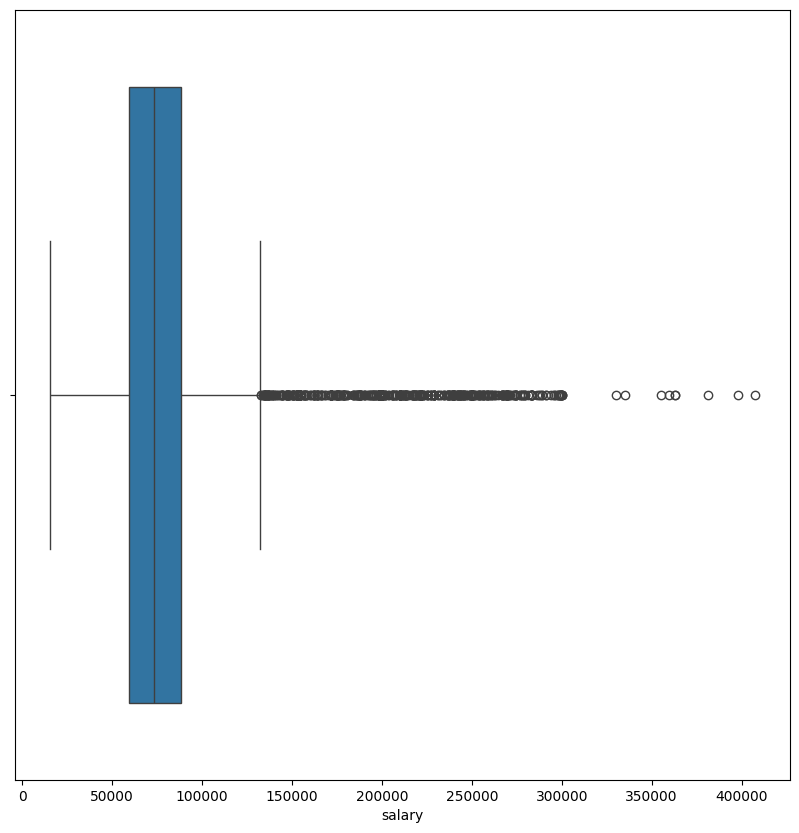

In [118]:
plt.figure(figsize=(10,10))

sns.boxplot(data=df_loyalty, x="salary");

In [126]:
# Considerando que tenemos un 25% de nulos en la variable salary, con presencia de outliers, usaremos la tecnica avanzada que menos altere los datos.
# Probaremos con IterativeImputer y KNNImputer y haremos una comparacion

iterative_imputer = IterativeImputer(random_state=42, max_iter=20)  

iterative_imputado = iterative_imputer.fit_transform(df_loyalty[["salary"]])

df_loyalty[["salary_iter"]] = iterative_imputado

df_loyalty.head(2)

,loyalty_number,country,province,city,postal_code,gender,education,salary,marital_status,loyalty_card,clv,enrollment_type,enrollment_year,enrollment_month,cancellation_year,cancellation_month,salary_iter
0,480934,Canada,Ontario,Toronto,M2Z 4K1,Female,Bachelor,83236.0,Married,Star,3839.14,Standard,2016,2,NaN,NaN,83236.000000
1,549612,Canada,Alberta,Edmonton,T3G 6Y6,Male,College,NaN,Divorced,Star,3839.61,Standard,2016,3,NaN,NaN,79429.572642


In [127]:
knn_imputer = KNNImputer(n_neighbors=5)  # el numero de vecinos suele ser 5 pq si no tarda un monton

columna_imputada_knn = knn_imputer.fit_transform(df_loyalty[["salary"]])


df_loyalty[["salary_knn"]] = columna_imputada_knn

df_loyalty.head(2)

,loyalty_number,country,province,city,postal_code,gender,education,salary,marital_status,loyalty_card,clv,enrollment_type,enrollment_year,enrollment_month,cancellation_year,cancellation_month,salary_iter,salary_knn
0,480934,Canada,Ontario,Toronto,M2Z 4K1,Female,Bachelor,83236.0,Married,Star,3839.14,Standard,2016,2,NaN,NaN,83236.000000,83236.000000
1,549612,Canada,Alberta,Edmonton,T3G 6Y6,Male,College,NaN,Divorced,Star,3839.61,Standard,2016,3,NaN,NaN,79429.572642,79429.572642


In [128]:
# comparamos
df_loyalty[['salary', 'salary_knn', 'salary_iter']].agg(["mean", "median"]).T

,mean,median
salary,79429.572642,73510.000000
salary_knn,79429.572642,79429.572642
salary_iter,79429.572642,79429.572642


In [129]:
# nos arrojó los mismos datos asi que nos quedamos con IterativeImputer, cambiamos la columna

df_loyalty.drop(columns=['salary', 'salary_knn'], inplace=True)

In [130]:
df_loyalty.columns

Index(['loyalty_number', 'country', 'province', 'city', 'postal_code',
       'gender', 'education', 'marital_status', 'loyalty_card', 'clv',
       'enrollment_type', 'enrollment_year', 'enrollment_month',
       'cancellation_year', 'cancellation_month', 'salary_iter'],
      dtype='object')

In [131]:
df_loyalty.rename(columns={"salary_iter": "salary"}, inplace=True)

df_loyalty.head(2)

,loyalty_number,country,province,city,postal_code,gender,education,marital_status,loyalty_card,clv,enrollment_type,enrollment_year,enrollment_month,cancellation_year,cancellation_month,salary
0,480934,Canada,Ontario,Toronto,M2Z 4K1,Female,Bachelor,Married,Star,3839.14,Standard,2016,2,NaN,NaN,83236.000000
1,549612,Canada,Alberta,Edmonton,T3G 6Y6,Male,College,Divorced,Star,3839.61,Standard,2016,3,NaN,NaN,79429.572642


In [133]:
col = df_loyalty.pop('salary')
df_loyalty.insert(7, 'salary', col)

df_loyalty.head(2)

,loyalty_number,country,province,city,postal_code,gender,education,salary,marital_status,loyalty_card,clv,enrollment_type,enrollment_year,enrollment_month,cancellation_year,cancellation_month
0,480934,Canada,Ontario,Toronto,M2Z 4K1,Female,Bachelor,83236.000000,Married,Star,3839.14,Standard,2016,2,NaN,NaN
1,549612,Canada,Alberta,Edmonton,T3G 6Y6,Male,College,79429.572642,Divorced,Star,3839.61,Standard,2016,3,NaN,NaN


In [ ]:
# no redondear los datos de salary porque pueden cambiar los resultados, mejor redondear al visualizar

In [134]:
df_loyalty.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16737 entries, 0 to 16736
Data columns (total 16 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   loyalty_number      16737 non-null  int64  
 1   country             16737 non-null  object 
 2   province            16737 non-null  object 
 3   city                16737 non-null  object 
 4   postal_code         16737 non-null  object 
 5   gender              16737 non-null  object 
 6   education           16737 non-null  object 
 7   salary              16737 non-null  float64
 8   marital_status      16737 non-null  object 
 9   loyalty_card        16737 non-null  object 
 10  clv                 16737 non-null  float64
 11  enrollment_type     16737 non-null  object 
 12  enrollment_year     16737 non-null  int64  
 13  enrollment_month    16737 non-null  int64  
 14  cancellation_year   2067 non-null   float64
 15  cancellation_month  2067 non-null   float64
dtypes: f

In [136]:
def resumen_nulos(df):
    nulos = (df.isnull().sum() / len(df) * 100).reset_index()
    nulos.columns = ["columna", "%_nulos"]
    return nulos[nulos["%_nulos"] > 0]

In [139]:
print(resumen_nulos(df_flight_activity))

print("=" * 100)

print(resumen_nulos(df_loyalty))

Empty DataFrame
Columns: [columna, %_nulos]
Index: []
               columna    %_nulos
14   cancellation_year  87.650117
15  cancellation_month  87.650117


In [ ]:
# los datos nulos de cancellation_year y cancellation_month no son nulos reales, son datos que confirman que los clientes siguen enrolled por ende estamos hablando de un evento inexistente. 
# Dejamos los nulos como están.

# Una vez limpios los df, guardamos

In [ ]:
# comprobamos si los registros de los clientes en flight_activity son los mismos clientes de dataframe de loyalty


set(df_flight_activity["loyalty_number"].unique()) == set(df_loyalty["loyalty_number"].unique())

True

In [142]:
# unimos

df_unido_customer = df_flight_activity.merge(df_loyalty, how="inner", on="loyalty_number")

In [143]:
# preferiblemente guardar los CSV de cada dataframe y tambien el de unido

df_flight_activity.to_csv("files_limpios/customer_flight_activity_limpio.csv", index=False)

df_loyalty.to_csv("files_limpios/customer_loyalty_history_limpio.csv", index=False)

df_unido_customer.to_csv("files_limpios/customer_completo_limpio.csv", index=False)